In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class SimpleSelfAttention(nn.Module):
    def __init__(self, embed_size):
        super(SimpleSelfAttention, self).__init__()
        
        self.embed_size = embed_size
        
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        attention_scores = torch.matmul(Q, K.transpose(-2, -1))
        attention_scores = attention_scores / (self.embed_size ** 0.5)

        attention_weights = F.softmax(attention_scores, dim=-1)

        output = torch.matmul(attention_weights, V)
        return output, attention_weights

In [3]:
embed_size = 16
seq_len = 5
batch_size = 1

x = torch.rand(batch_size, seq_len, embed_size)

model = SimpleSelfAttention(embed_size)

output, weights = model(x)

print("Output shape:", output.shape)
print("Attention shape:", weights.shape)

Output shape: torch.Size([1, 5, 16])
Attention shape: torch.Size([1, 5, 5])


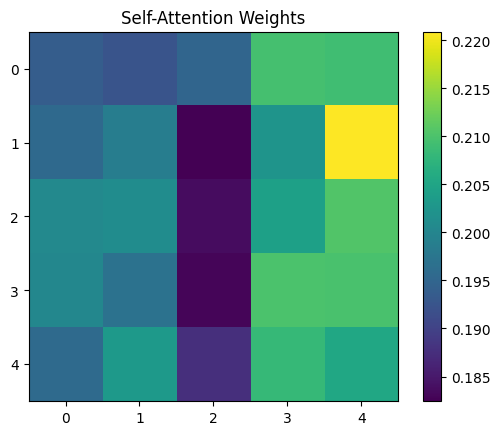

In [5]:
import matplotlib.pyplot as plt
import os

# créer dossier si nécessaire
os.makedirs("../images/attention_maps", exist_ok=True)

plt.figure()

plt.imshow(weights[0].detach().numpy(), cmap="viridis")
plt.title("Self-Attention Weights")
plt.colorbar()

# sauvegarde image
plt.savefig("../images/attention_maps/self_attention_weights.png")

plt.show()